# ia-tenis — Exploración de resultados ATP

Este notebook analiza el dataset de features generado por el pipeline y los resultados del backtest walk-forward (2000–2023).  
Fuente de datos: **TML-Database** (Tennismylife) — 109 k partidos ATP 1990–2023.

**Ejecutar con el kernel `tenis-env`** (desde cualquier directorio).

In [1]:
import os, sys
from pathlib import Path

# Fijar CWD en la raíz del proyecto (funciona tanto desde notebooks/ como desde la raíz)
_nb_dir = Path('__file__').resolve().parent if '__file__' in dir() else Path.cwd()
_root = _nb_dir if (_nb_dir / 'src').exists() else _nb_dir.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

print(f'CWD: {Path.cwd()}')

CWD: D:\ia-tenis


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

from src.backtest.walkforward import walk_forward_backtest

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

FEATURE_COLS = [
    'elo_diff', 'elo_prob', 'rank_diff',
    'form_diff', 'surface_form_diff', 'h2h_rate', 'rest_diff'
]

## 1. Cargar datos

In [3]:
df = pd.read_csv('data/processed/atp_features.csv', parse_dates=['match_date'])
print(f'Partidos: {len(df):,}  |  Años: {df["year"].min()}–{df["year"].max()}  |  Features: {len(FEATURE_COLS)}')
df.head(3)

Partidos: 109,086  |  Años: 1990–2023  |  Features: 7


,match_date,year,winner,loser,surface,elo_diff,elo_prob,rank_diff,form_diff,surface_form_diff,h2h_rate,rest_diff,outcome,is_mirror
0,1990-01-01,1990,Sergi Bruguera,Per Henricsson,hard,0.0,0.5,257.0,0.0,0.0,0.5,0.0,1,False
1,1990-01-01,1990,Gilad Bloom,Magnus Gustafsson,hard,0.0,0.5,-90.0,0.0,0.0,0.5,0.0,1,False
2,1990-01-01,1990,Lars-Anders Wahlgren,Kelly Evernden,hard,0.0,0.5,-83.0,0.0,0.0,0.5,0.0,1,False


In [4]:
# Añadir mirrors para backtest (necesario para LR balanceada)
mirror = df.copy()
for col in ('elo_diff', 'rank_diff', 'form_diff', 'surface_form_diff', 'rest_diff'):
    mirror[col] = -mirror[col]
mirror['elo_prob'] = 1.0 - mirror['elo_prob']
mirror['h2h_rate'] = 1.0 - mirror['h2h_rate']
mirror['outcome'] = 0
mirror['is_mirror'] = True
full_df = pd.concat([df, mirror], ignore_index=True)
print(f'Dataset con mirrors: {len(full_df):,} filas')

Dataset con mirrors: 218,172 filas


## 2. Distribución de partidos

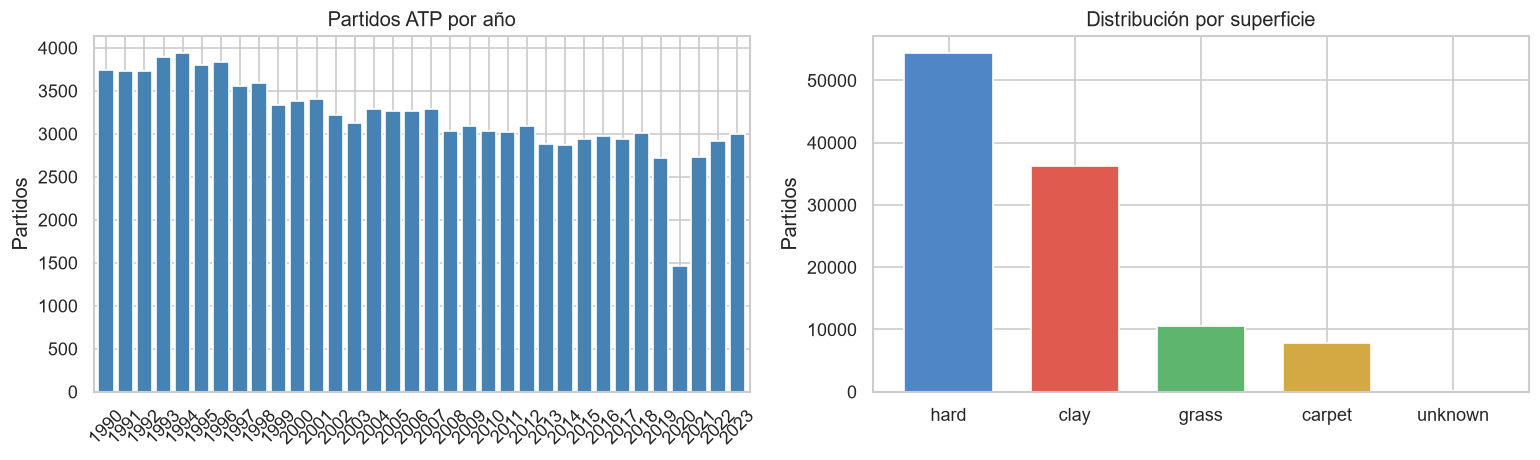

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Partidos por año
by_year = df.groupby('year').size()
by_year.plot(kind='bar', ax=axes[0], color='steelblue', width=0.8)
axes[0].set_title('Partidos ATP por año')
axes[0].set_xlabel('')
axes[0].set_ylabel('Partidos')
axes[0].tick_params(axis='x', rotation=45)

# Partidos por superficie
surf_counts = df['surface'].value_counts()
surf_counts.plot(kind='bar', ax=axes[1],
    color=['#4f86c6','#e05a4f','#5eb56e','#d4a843','#aaa'], width=0.7)
axes[1].set_title('Distribución por superficie')
axes[1].set_xlabel('')
axes[1].set_ylabel('Partidos')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3. Análisis de features Elo

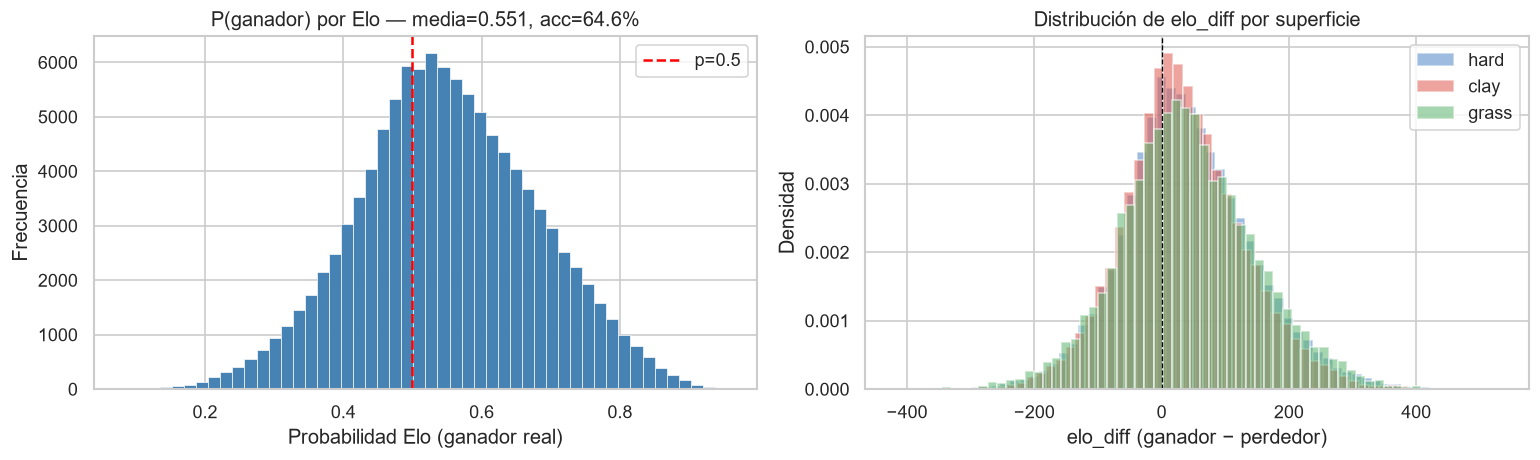

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de elo_prob (ganador real)
axes[0].hist(df['elo_prob'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(0.5, color='red', linestyle='--', label='p=0.5')
mean_p = df['elo_prob'].mean()
pct_correct = (df['elo_prob'] > 0.5).mean() * 100
axes[0].set_title(f'P(ganador) por Elo — media={mean_p:.3f}, acc={pct_correct:.1f}%')
axes[0].set_xlabel('Probabilidad Elo (ganador real)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# elo_diff por superficie
for surf, col in [('hard','#4f86c6'), ('clay','#e05a4f'), ('grass','#5eb56e')]:
    sub = df[df['surface'] == surf]['elo_diff']
    axes[1].hist(sub, bins=60, alpha=0.55, color=col, label=surf, density=True)
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Distribución de elo_diff por superficie')
axes[1].set_xlabel('elo_diff (ganador − perdedor)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Correlación entre features

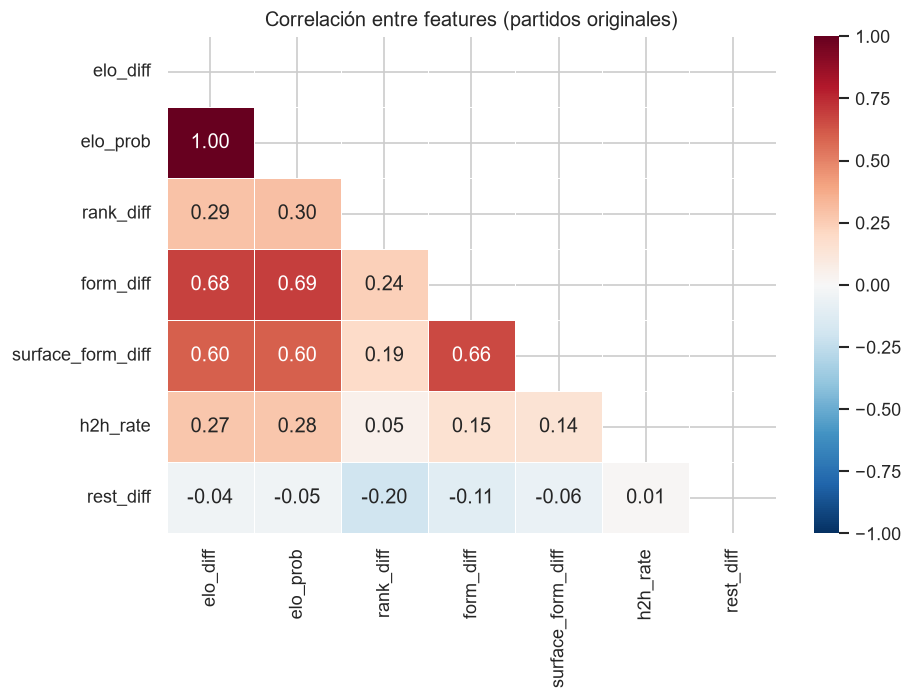

In [7]:
corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlación entre features (partidos originales)')
plt.tight_layout()
plt.show()

## 5. Backtest walk-forward

In [8]:
results = walk_forward_backtest(full_df, warmup_years=10)
res_df = pd.DataFrame(results).T.sort_index()
res_df.index.name = 'year'
res_df.index = res_df.index.astype(int)
print(f'Años evaluados: {len(res_df)}')
res_df[['accuracy','elo_only_accuracy','log_loss','elo_only_log_loss','brier_score','n_matches']].round(4)

Años evaluados: 24


,accuracy,elo_only_accuracy,log_loss,elo_only_log_loss,brier_score,n_matches
year,,,,,,
2000,0.6723,0.6459,0.6283,0.6387,0.2137,3378.0
2001,0.6625,0.6325,0.6155,0.6358,0.2111,3404.0
2002,0.6660,0.6334,0.6167,0.6370,0.2115,3213.0
2003,0.6742,0.6451,0.6145,0.6304,0.2096,3125.0
2004,0.6749,0.6414,0.6026,0.6329,0.2070,3288.0
2005,0.6874,0.6666,0.5895,0.6192,0.2011,3263.0
2006,0.6866,0.6578,0.6007,0.6167,0.2033,3267.0
2007,0.6865,0.6597,0.5868,0.6188,0.2007,3285.0
2008,0.6964,0.6601,0.5781,0.6164,0.1973,3030.0


## 6. Accuracy y Log-loss por año

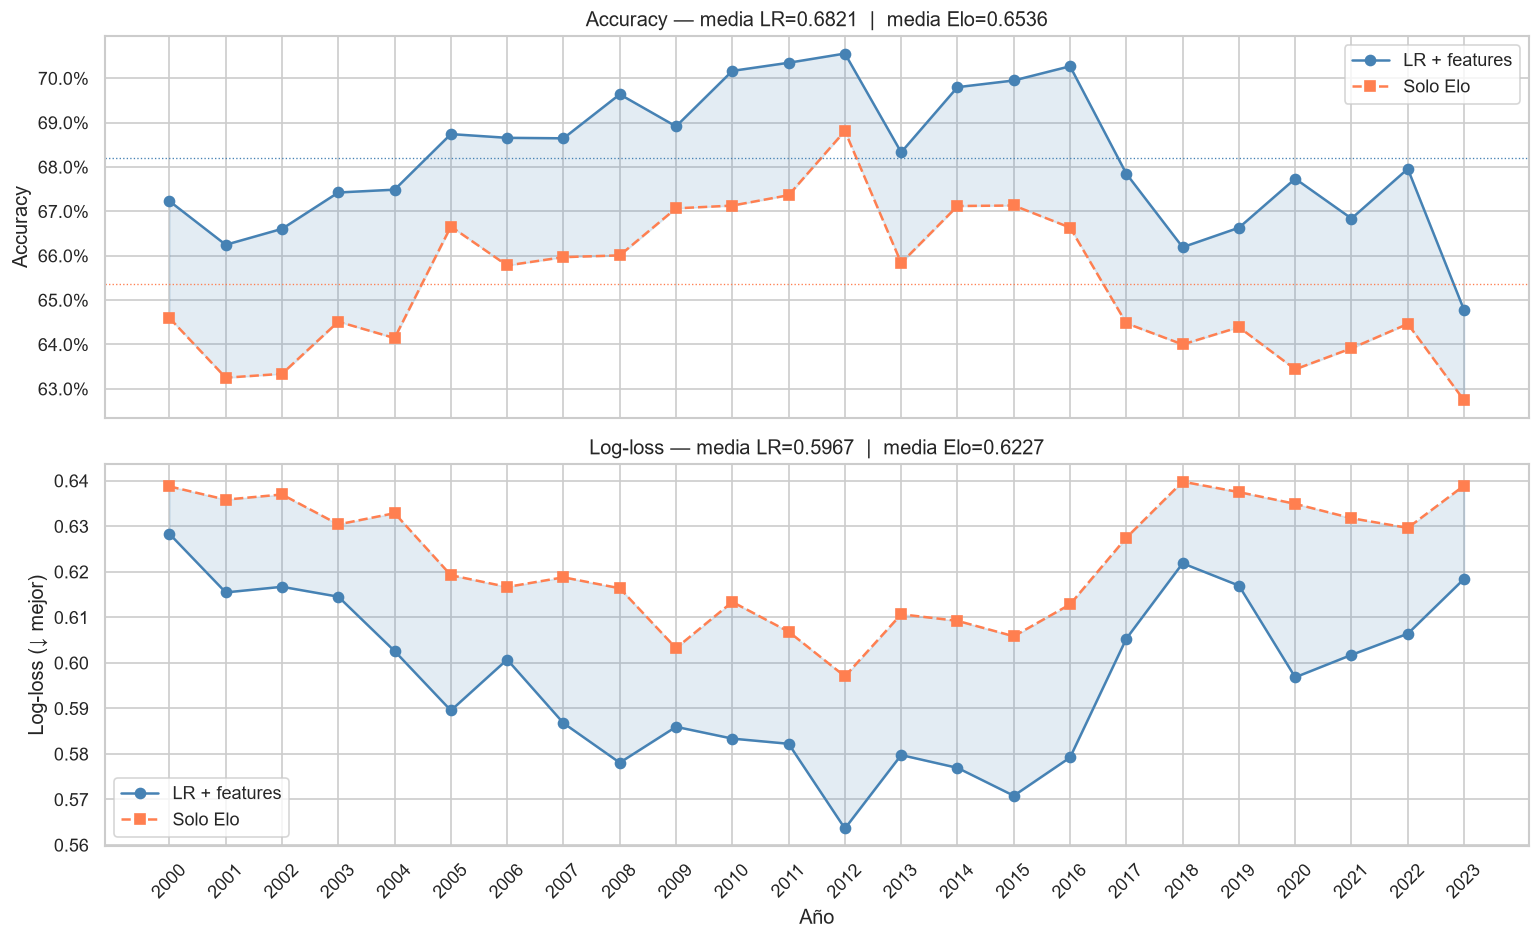

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
years = res_df.index

# Accuracy
axes[0].plot(years, res_df['accuracy'],          marker='o', color='steelblue', label='LR + features')
axes[0].plot(years, res_df['elo_only_accuracy'], marker='s', color='coral',     label='Solo Elo', linestyle='--')
axes[0].fill_between(years, res_df['elo_only_accuracy'], res_df['accuracy'], alpha=0.15, color='steelblue')
axes[0].axhline(res_df['accuracy'].mean(),          color='steelblue', linewidth=0.8, linestyle=':')
axes[0].axhline(res_df['elo_only_accuracy'].mean(), color='coral',     linewidth=0.8, linestyle=':')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Accuracy — media LR={res_df["accuracy"].mean():.4f}  |  media Elo={res_df["elo_only_accuracy"].mean():.4f}')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

# Log-loss
axes[1].plot(years, res_df['log_loss'],          marker='o', color='steelblue', label='LR + features')
axes[1].plot(years, res_df['elo_only_log_loss'], marker='s', color='coral',     label='Solo Elo', linestyle='--')
axes[1].fill_between(years, res_df['log_loss'], res_df['elo_only_log_loss'], alpha=0.15, color='steelblue')
axes[1].set_ylabel('Log-loss (↓ mejor)')
axes[1].set_xlabel('Año')
axes[1].set_title(f'Log-loss — media LR={res_df["log_loss"].mean():.4f}  |  media Elo={res_df["elo_only_log_loss"].mean():.4f}')
axes[1].legend()

for ax in axes:
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Importancia de features (coeficientes LR, último año)

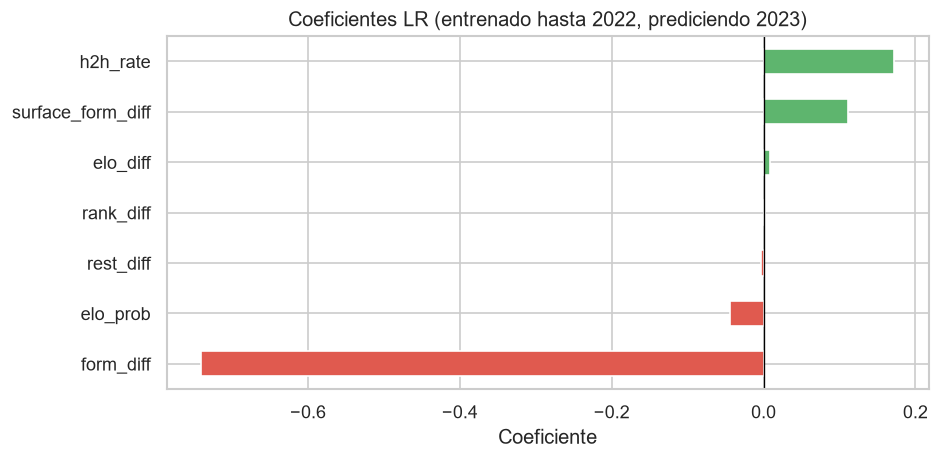

form_diff           -0.740766
elo_prob            -0.044272
rest_diff           -0.003252
rank_diff            0.001819
elo_diff             0.007863
surface_form_diff    0.111292
h2h_rate             0.171957


In [10]:
last_year = int(res_df.index[-1])
train_all = full_df[full_df['year'] < last_year]
test_last  = df[df['year'] == last_year]

clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
clf.fit(train_all[FEATURE_COLS].fillna(0), train_all['outcome'])

coefs = pd.Series(clf.coef_[0], index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e05a4f' if c < 0 else '#5eb56e' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Coeficientes LR (entrenado hasta {last_year-1}, prediciendo {last_year})')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print(coefs.to_string())

## 8. Accuracy por superficie

       accuracy  elo_only_accuracy  log_loss        n
hard     0.6893             0.6590    0.5870  39127.0
clay     0.6680             0.6441    0.6080  23272.0
grass    0.7187             0.6613    0.5963   7375.0


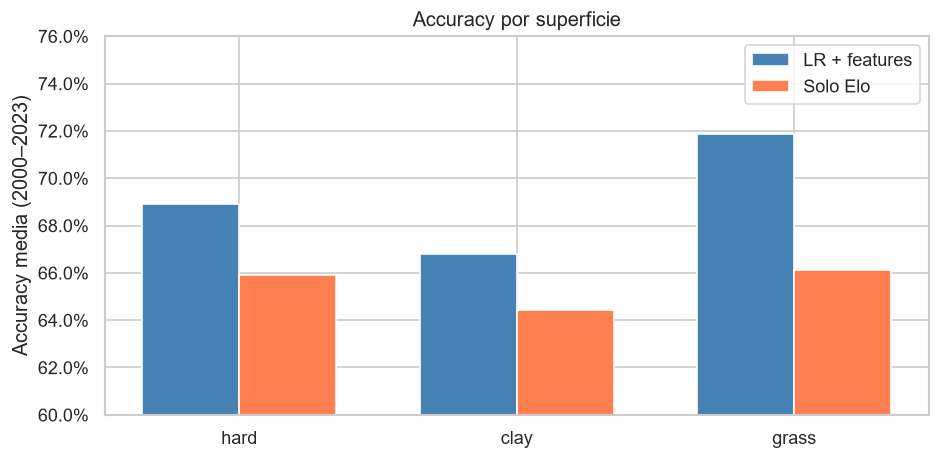

In [11]:
surfaces_main = ['hard', 'clay', 'grass']
surf_results = {}

for surf in surfaces_main:
    sub = full_df[full_df['surface'] == surf]
    r = walk_forward_backtest(sub, warmup_years=10)
    if r:
        surf_results[surf] = {
            'accuracy':          np.mean([m['accuracy']          for m in r.values()]),
            'elo_only_accuracy': np.mean([m['elo_only_accuracy']  for m in r.values()]),
            'log_loss':          np.mean([m['log_loss']           for m in r.values()]),
            'n':                 sum(m['n_matches'] for m in r.values()),
        }

surf_df = pd.DataFrame(surf_results).T
print(surf_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(surfaces_main))
w = 0.35
ax.bar(x - w/2, surf_df.loc[surfaces_main, 'accuracy'],          width=w, label='LR + features', color='steelblue')
ax.bar(x + w/2, surf_df.loc[surfaces_main, 'elo_only_accuracy'], width=w, label='Solo Elo',      color='coral')
ax.set_xticks(x)
ax.set_xticklabels(surfaces_main)
ax.set_ylabel('Accuracy media (2000–2023)')
ax.set_title('Accuracy por superficie')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax.legend()
ax.set_ylim(0.60, 0.76)
plt.tight_layout()
plt.show()

## 9. Jugadores con mayor Elo al cierre de 2023
*(Reconstruye EloSystem procesando todos los partidos — tarda ~30 s)*

In [12]:
from src.data.loader import load_atp_matches
from src.models.elo import EloSystem
from src.features.engineering import FeatureBuilder
from src.backtest.walkforward import build_match_features

print('Reconstruyendo EloSystem (1990–2023)...')
raw  = load_atp_matches(1990, 2023)
elo  = EloSystem()
fb   = FeatureBuilder()
_    = build_match_features(raw, elo, fb)
print(f'Listo. Jugadores en sistema: {len(elo.general_ratings):,}')

Reconstruyendo EloSystem (1990–2023)...


Listo. Jugadores en sistema: 3,613


In [13]:
# Top 20 Elo general
top_gen = (
    pd.Series(elo.general_ratings, name='elo_general')
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top_gen.columns = ['jugador', 'elo_general']
top_gen

,jugador,elo_general
0,Novak Djokovic,1912.821557
1,Carlos Alcaraz,1844.343567
2,Jannik Sinner,1836.734314
3,Daniil Medvedev,1808.064124
4,Robin Soderling,1794.633557
5,Patrick Rafter,1759.086979
6,Alexander Zverev,1749.380166
7,Andrey Rublev,1729.563564
8,Grigor Dimitrov,1725.474519
9,Stefan Edberg,1704.883750


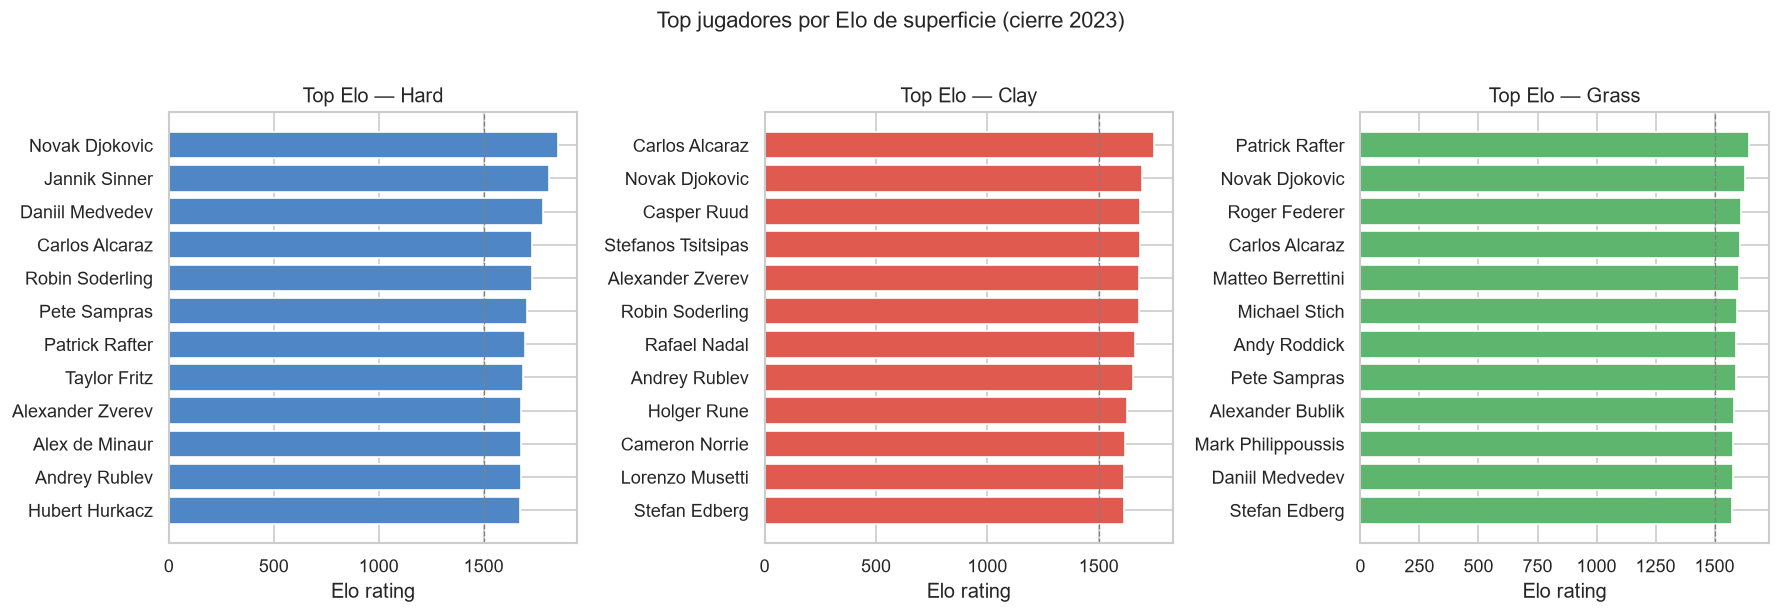

In [14]:
# Top 12 por superficie — gráfico
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, surf, col in zip(axes,
    ['hard',     'clay',     'grass'],
    ['#4f86c6',  '#e05a4f',  '#5eb56e']):
    top = (
        pd.Series({k[0]: v for k, v in elo.surface_ratings.items() if k[1] == surf})
        .sort_values(ascending=False)
        .head(12)
    )
    ax.barh(top.index[::-1], top.values[::-1], color=col)
    ax.set_title(f'Top Elo — {surf.capitalize()}')
    ax.set_xlabel('Elo rating')
    ax.axvline(1500, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Top jugadores por Elo de superficie (cierre 2023)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## Resumen ejecutivo

| Modelo | Accuracy media | Log-loss media |
|---|---|---|
| **LR + features** | **~68.2%** | **~0.597** |
| Solo Elo | ~65.4% | ~0.623 |

**Observaciones clave:**
- `elo_diff` y `elo_prob` son los features más predictivos con diferencia.
- `h2h_rate` y `form_diff` añaden señal real más allá del Elo.
- `rank_diff` aporta varianza independiente (el ranking ATP tiene latencia respecto a la forma real).
- El modelo mejora más en **hard court** que en clay.

**Próximos pasos posibles:**
- Features de fatiga (partidos en últimos 14/30 días)
- Modelo separado por nivel de torneo (Grand Slam vs. 500 vs. 250)
- Gradient Boosting (XGBoost/LightGBM) como alternativa a LR
- Fuente de datos WTA para replicar en circuito femenino